Diabetes Prediction Using Machine Learning

In [1]:
#File imported
from google.colab import files
uploaded=files.upload()

Saving diabetes_dataset.csv to diabetes_dataset.csv


In [2]:
#All libraries imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv('diabetes_dataset.csv')

In [3]:
#Check the uppermost to column to confirm file is imported or not
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
#To know no.of rows and columns in dataset
df.shape

(100000, 31)

In [5]:
#To know column names
df.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [6]:
#To know Total rows, Non-null values and Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [7]:
#checked any null value is present in any column or not
df.isnull().sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


In [8]:
#checked any dupliacte value is present in any column or not
df.duplicated().sum()

np.int64(0)

In [9]:
#Checked Target Distribution since target variable is diagnosed_diabetes
df['diagnosed_diabetes'].value_counts()

,count
diagnosed_diabetes,
1,59998
0,40002


In [10]:
#Checked Target Distribution in percentage since target variable is diagnosed_diabetes
df['diagnosed_diabetes'].value_counts(normalize=True)*100

,proportion
diagnosed_diabetes,
1,59.998
0,40.002


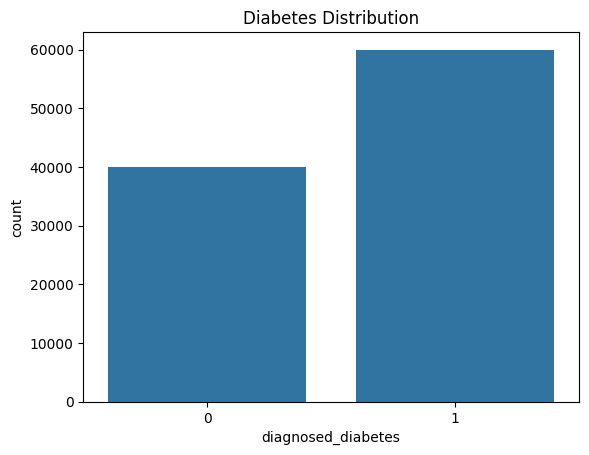

In [11]:
#Plot Target distribution
sns.countplot(x='diagnosed_diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()

In [12]:
#Finding Numerical & Categorical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diagnosed_diabetes'],
      dtype='object')

Categorical Columns:
Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'diabetes_stage'],
      dtype='object')


#Not focusing on all 30 columns just focused on important columns

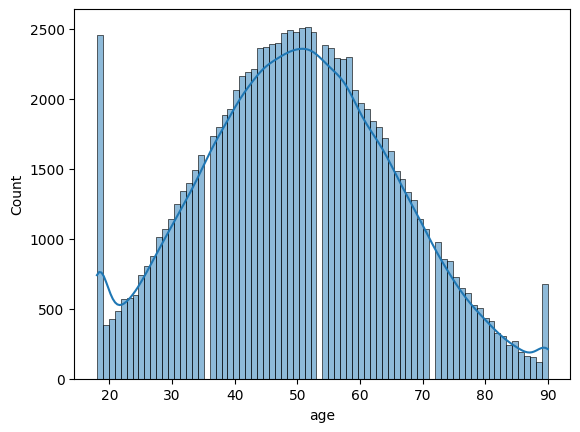

In [13]:
#Age
sns.histplot(df['age'], kde=True)
plt.show()

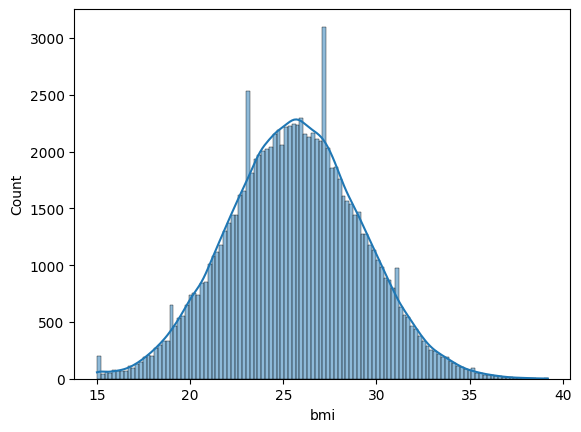

In [14]:
#BMI
sns.histplot(df['bmi'], kde=True)
plt.show()

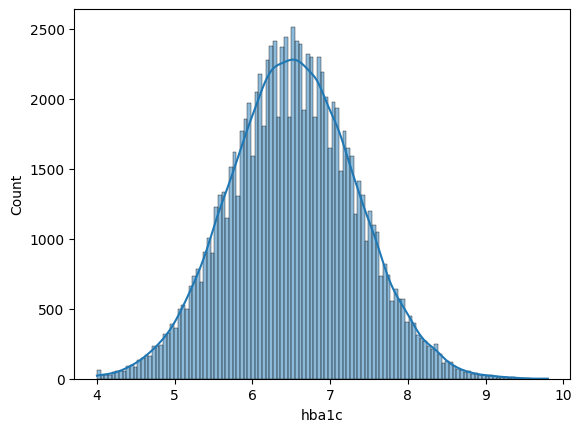

In [15]:
#HbA1c
sns.histplot(df['hba1c'], kde=True)
plt.show()

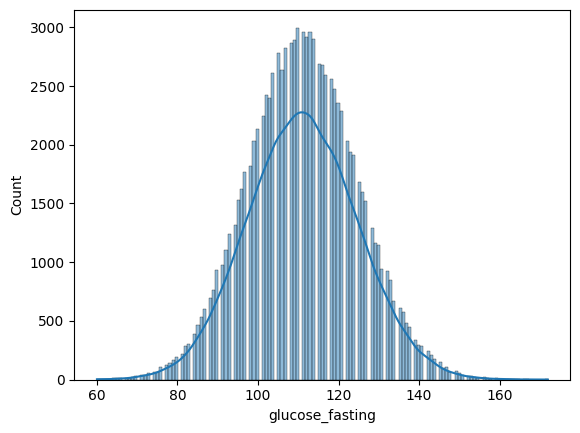

In [16]:
#glucose_fasting
sns.histplot(df['glucose_fasting'], kde=True)
plt.show()

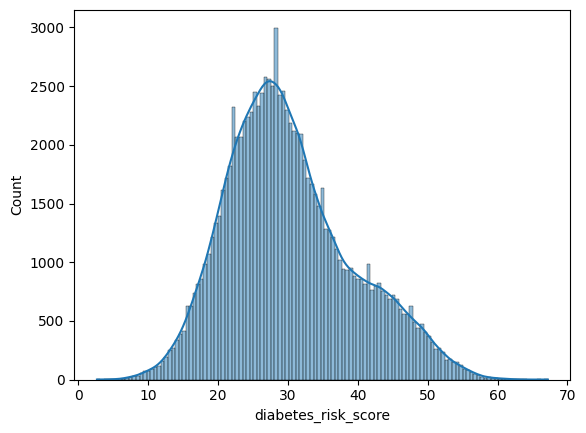

In [17]:
#diabetes_risk_score
sns.histplot(df['diabetes_risk_score'], kde=True)
plt.show()

Correlation Heatmap

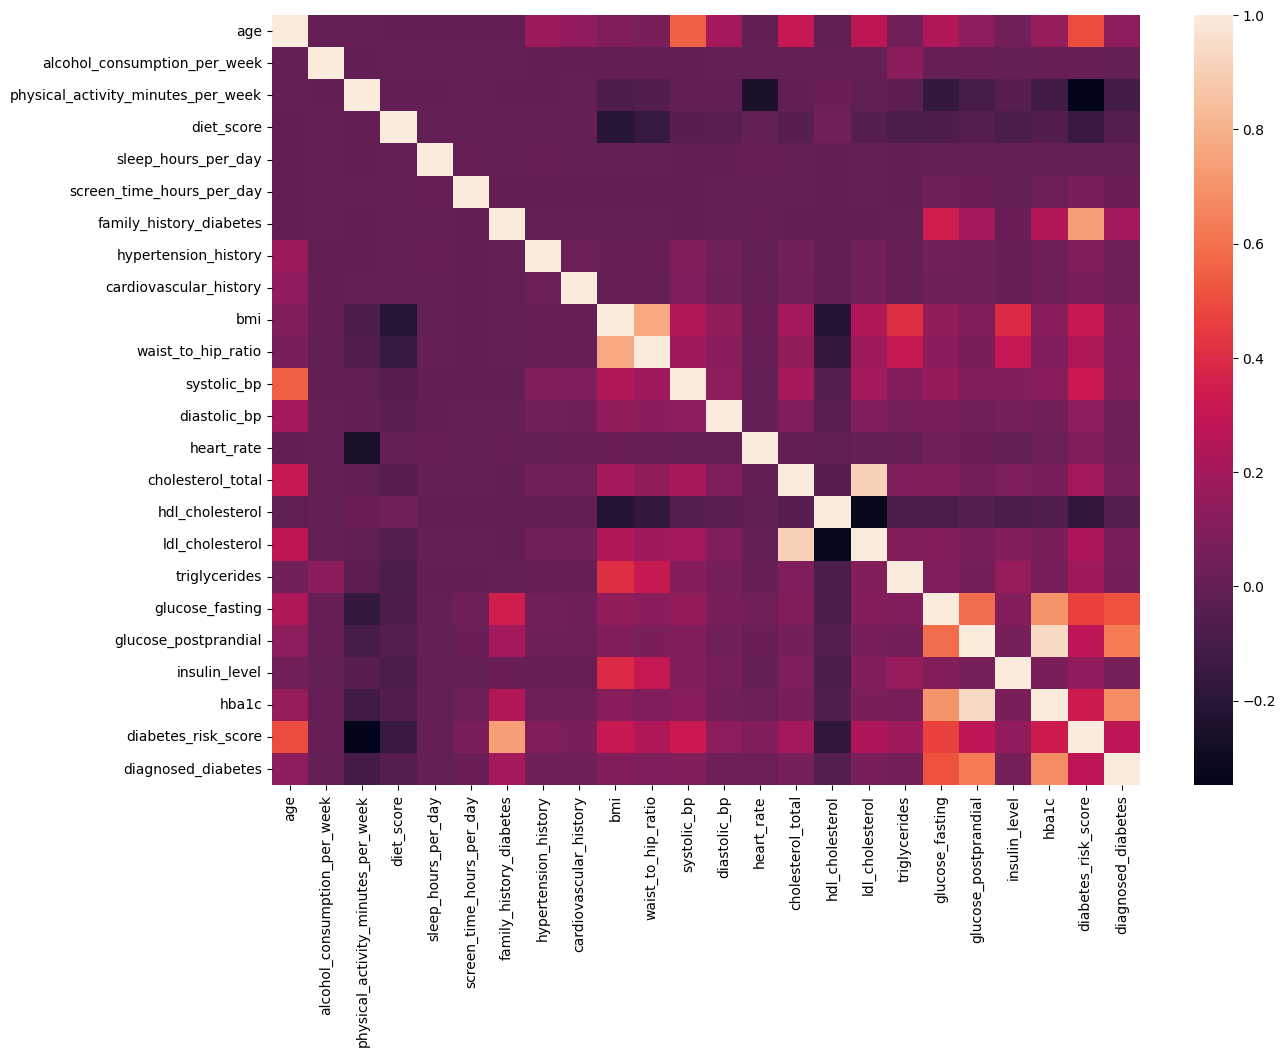

In [18]:
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr)
plt.show()

Feature Selection

In [19]:
df[['diabetes_stage','diagnosed_diabetes']].head()

,diabetes_stage,diagnosed_diabetes
0,Type 2,1
1,No Diabetes,0
2,Type 2,1
3,Type 2,1
4,Type 2,1


In [20]:
pd.crosstab(df['diabetes_stage'],df['diagnosed_diabetes'])

diagnosed_diabetes,0,1
diabetes_stage,,
Gestational,120,158
No Diabetes,7981,0
Pre-Diabetes,31845,0
Type 1,56,66
Type 2,0,59774


Encoding

In [21]:
pd.get_dummies(df)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,employment_status_Student,employment_status_Unemployed,smoking_status_Current,smoking_status_Former,smoking_status_Never,diabetes_stage_Gestational,diabetes_stage_No Diabetes,diabetes_stage_Pre-Diabetes,diabetes_stage_Type 1,diabetes_stage_Type 2
0,58,0,215,5.7,7.9,7.9,0,0,0,30.5,...,False,False,False,False,True,False,False,False,False,True
1,48,1,143,6.7,6.5,8.7,0,0,0,23.1,...,False,False,False,True,False,False,True,False,False,False
2,60,1,57,6.4,10.0,8.1,1,0,0,22.2,...,False,True,False,False,True,False,False,False,False,True
3,74,0,49,3.4,6.6,5.2,0,0,0,26.8,...,False,False,False,False,True,False,False,False,False,True
4,46,1,109,7.2,7.4,5.0,0,0,0,21.2,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,1,136,8.3,6.4,4.5,0,0,0,29.8,...,False,True,False,True,False,False,False,True,False,False
99996,41,3,76,8.8,6.8,4.8,0,0,0,26.5,...,False,False,False,False,True,False,False,True,False,False
99997,57,4,121,9.9,5.0,6.1,0,0,1,25.6,...,False,False,False,True,False,False,True,False,False,False
99998,47,3,52,5.9,6.7,0.5,0,1,0,26.8,...,False,False,False,False,True,False,False,True,False,False


Train-Test Split

In [22]:
X = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
pd.crosstab(
    df['diabetes_stage'],
    df['diagnosed_diabetes']
)

diagnosed_diabetes,0,1
diabetes_stage,,
Gestational,120,158
No Diabetes,7981,0
Pre-Diabetes,31845,0
Type 1,56,66
Type 2,0,59774


In [25]:
#Remove Leakage Column
df = df.drop('diabetes_stage', axis=1)

In [26]:
#Prepare Features and Target
X = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']

In [27]:
#Encode Categorical Columns
cat_cols = X.select_dtypes(include='object').columns
print(cat_cols)

Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status'],
      dtype='object')


In [28]:
#Encoding
X = pd.get_dummies(X, drop_first=True)

In [29]:
X.shape

(100000, 41)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
X_train.shape
X_test.shape

(20000, 41)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.83975


In [36]:
print(confusion_matrix(y_test, y_pred))

[[ 6245  1832]
 [ 1373 10550]]


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.77      0.80      8077
           1       0.85      0.88      0.87     11923

    accuracy                           0.84     20000
   macro avg       0.84      0.83      0.83     20000
weighted avg       0.84      0.84      0.84     20000



In [38]:
print("Train Score:", model.score(X_train, y_train))

print("Test Score:", model.score(X_test, y_test))

Train Score: 0.843925
Test Score: 0.83975


In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.80845


In [40]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.8623


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.9202


In [42]:
from sklearn.metrics import classification_report

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      8077
           1       1.00      0.87      0.93     11923

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



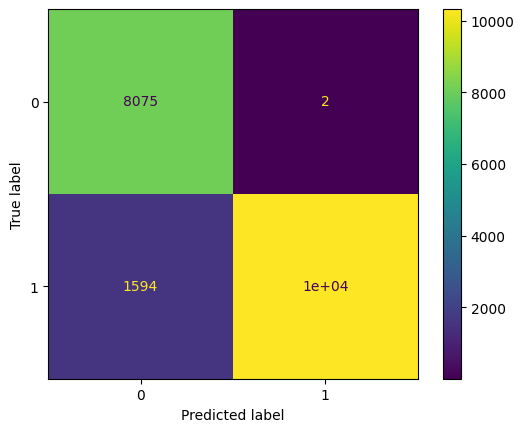

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)
plt.show()

In [44]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
21,hba1c,0.422707
19,glucose_postprandial,0.196395
18,glucose_fasting,0.091287
22,diabetes_risk_score,0.028280
2,physical_activity_minutes_per_week,0.017163
9,bmi,0.015213
17,triglycerides,0.015072
20,insulin_level,0.014763
0,age,0.014701
14,cholesterol_total,0.014461


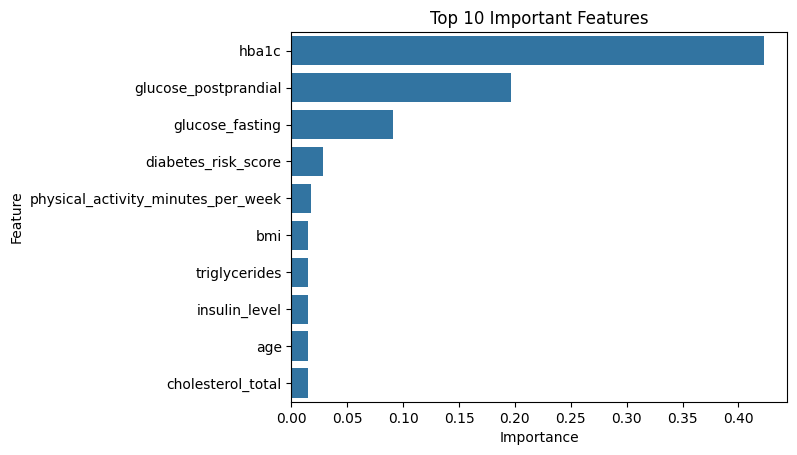

In [45]:
top_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top 10 Important Features')
plt.show()